# Statistical Analysis

This notebook tests whether 2025 NWS staffing cuts produced statistically significant changes in warning performance. All tests use event-level data from `data/03_cleaning/events.csv` and storm reports from `data/03_cleaning/stormreports.csv`.

**Seven tests, in order:**

1. Primary logistic regression: SV verify rate 2025 vs. 2020–2024 (WFO + month FE)
2. Phenomena interaction: Is the SV drop significantly larger than TO/FF?
3. Volume control: Does the FAR increase survive controlling for storm activity?
4. Treatment timeline: Does the signal track the staffing phases (ITS)?
5. Co-occurrence / triage test: Does SV performance drop more on high-triage days?
6. Overnight closure dose-response (negative result)
7. Sensitivity checks: all-CONUS, alternate treatment dates, lead0 exclusions

In [1]:
import sys
import logging
import warnings
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.formula.api as smf
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.WARNING)

from src.analysis.constants import (
    NON_CONUS, OVERNIGHT_CLOSED, PHENOMENA, PHENOMENA_LABELS, PHENOMENA_COLORS,
)
from src.analysis.data import load_events, load_stormreports, filter_conus, get_p75_wfos
from src.analysis.stats import sig_stars, phase_label

CLEANED_DIR = Path("../data/03_cleaning")
IMG_DIR     = Path("../img")
IMG_DIR.mkdir(exist_ok=True)

events       = load_events(CLEANED_DIR)
stormreports = load_stormreports(CLEANED_DIR)

conus    = filter_conus(events)
p75_wfos = get_p75_wfos(events)

print("events:", conus.shape)
for phen in PHENOMENA:
    n = conus[conus["phenomena"] == phen]["wfo"].isin(p75_wfos[phen]).sum()
    print(f"  {phen} top-quartile events: {n:,} ({len(p75_wfos[phen])} WFOs)")

/Users/crudman/Documents/GitHub/MSDS692/src/analysis/data.py:33: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["issue"].dt.to_period("M")


events: (161086, 22)
  TO top-quartile events: 8,999 (27 WFOs)
  SV top-quartile events: 58,042 (29 WFOs)
  FF top-quartile events: 14,375 (29 WFOs)


/Users/crudman/Documents/GitHub/MSDS692/src/analysis/data.py:49: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["valid"].dt.to_period("M")


## Test 1 — Primary logistic regression: SV verify rate in 2025

**Model:** `verify ~ year2025 + C(wfo) + C(month)` — event-level logistic regression restricted to top-quartile SV WFOs.

**Interpretation:** The coefficient on `year2025` estimates the change in log-odds of a warning being verified in 2025 vs. 2020–2024, after holding WFO identity and month of year constant. A negative coefficient means fewer warnings verified per event in 2025.

In [2]:
def run_primary_logit(phen, wfo_set, label="top-quartile"):
    """Logistic regression: verify ~ year2025 + C(wfo) + C(month)."""
    df = conus[
        (conus["phenomena"] == phen) &
        (conus["wfo"].isin(wfo_set))
    ].copy()
    df["verify_int"] = df["verify"].astype(int)

    model  = smf.logit("verify_int ~ year2025 + C(wfo) + C(month)", data=df)
    result = model.fit(disp=False, maxiter=200)

    coef  = result.params["year2025"]
    se    = result.bse["year2025"]
    pval  = result.pvalues["year2025"]
    ci_lo, ci_hi = result.conf_int().loc["year2025"]
    or_   = np.exp(coef)
    or_lo, or_hi = np.exp(ci_lo), np.exp(ci_hi)

    print(f"{phen} ({label})  n={len(df):,}  WFOs={df['wfo'].nunique()}")
    print(f"  year2025 coef: {coef:+.4f}  SE={se:.4f}  p={pval:.4f}")
    print(f"  OR: {or_:.3f}  95% CI [{or_lo:.3f}, {or_hi:.3f}]")
    print()
    return {"phen": phen, "label": label, "n": len(df),
            "coef": coef, "se": se, "pval": pval,
            "or": or_, "or_lo": or_lo, "or_hi": or_hi,
            "result": result}

results_t1 = {}
for phen in ["SV", "TO", "FF"]:
    results_t1[phen] = run_primary_logit(phen, p75_wfos[phen])

SV (top-quartile)  n=58,042  WFOs=29
  year2025 coef: -0.1895  SE=0.0221  p=0.0000
  OR: 0.827  95% CI [0.792, 0.864]

TO (top-quartile)  n=8,999  WFOs=27
  year2025 coef: -0.1502  SE=0.0664  p=0.0238
  OR: 0.861  95% CI [0.755, 0.980]

FF (top-quartile)  n=14,375  WFOs=29
  year2025 coef: +0.0894  SE=0.0475  p=0.0597
  OR: 1.093  95% CI [0.996, 1.200]



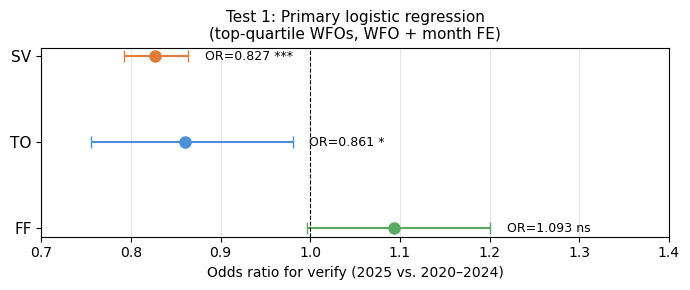

In [3]:
# Forest plot: odds ratios for year2025 across all three phenomena
fig, ax = plt.subplots(figsize=(7, 3))

phens = ["SV", "TO", "FF"]
y_pos = [2, 1, 0]

for i, phen in enumerate(phens):
    r = results_t1[phen]
    ax.errorbar(
        r["or"], y_pos[i],
        xerr=[[r["or"] - r["or_lo"]], [r["or_hi"] - r["or"]]],
        fmt="o", color=PHENOMENA_COLORS[phen], markersize=8, capsize=4, linewidth=1.5,
        label=phen
    )
    ax.text(r["or_hi"] + 0.01, y_pos[i], f'  OR={r["or"]:.3f} {sig_stars(r["pval"])}',
            va="center", fontsize=9)

ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(phens, fontsize=11)
ax.set_xlabel("Odds ratio for verify (2025 vs. 2020–2024)", fontsize=10)
ax.set_title("Test 1: Primary logistic regression\n(top-quartile WFOs, WFO + month FE)", fontsize=11)
ax.set_xlim(0.7, 1.4)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "analysis_01_primary_logit.png", dpi=150, bbox_inches="tight")
plt.show()

## Test 2 — Phenomena interaction: Is the SV drop significantly larger than TO/FF?

**Model:** Pooled logistic regression across all three phenomena with a `phenomena × year2025` interaction term. If the SV coefficient on `year2025` is significantly more negative than TO/FF, this supports the prioritization hypothesis. If all three degrade equally, it supports a general capacity story.

`SV` is the reference category so the interaction terms directly measure the TO/FF deviation from the SV baseline.

In [4]:
# Build pooled dataset: each phenomena uses its own top-quartile WFO set
pools = []
for phen in ["SV", "TO", "FF"]:
    sub = conus[
        (conus["phenomena"] == phen) &
        (conus["wfo"].isin(p75_wfos[phen]))
    ].copy()
    pools.append(sub)
pooled = pd.concat(pools, ignore_index=True)
pooled["verify_int"] = pooled["verify"].astype(int)

# SV as reference category
pooled["phenomena"] = pd.Categorical(pooled["phenomena"], categories=["SV", "TO", "FF"])

model_t2  = smf.logit(
    "verify_int ~ year2025 * C(phenomena) + C(wfo) + C(month)",
    data=pooled
)
result_t2 = model_t2.fit(disp=False, maxiter=200)

# Extract the interaction terms
params_of_interest = [c for c in result_t2.params.index
                      if "year2025" in c or c == "year2025"]
summary = pd.DataFrame({
    "coef":  result_t2.params[params_of_interest],
    "se":    result_t2.bse[params_of_interest],
    "pval":  result_t2.pvalues[params_of_interest],
    "OR":    np.exp(result_t2.params[params_of_interest]),
}).round(4)

print("Pooled model — year2025 terms (reference: SV):")
print(summary.to_string())
print()
print("Interpretation:")
print("  year2025                   = SV 2025 change (log-OR vs baseline)")
print("  year2025:C(phenomena)[T.TO] = additional TO change relative to SV")
print("  year2025:C(phenomena)[T.FF] = additional FF change relative to SV")

Pooled model — year2025 terms (reference: SV):
                               coef      se    pval      OR
year2025                    -0.1921  0.0219  0.0000  0.8253
year2025:C(phenomena)[T.TO]  0.1064  0.0673  0.1141  1.1123
year2025:C(phenomena)[T.FF]  0.2966  0.0509  0.0000  1.3453

Interpretation:
  year2025                   = SV 2025 change (log-OR vs baseline)
  year2025:C(phenomena)[T.TO] = additional TO change relative to SV
  year2025:C(phenomena)[T.FF] = additional FF change relative to SV


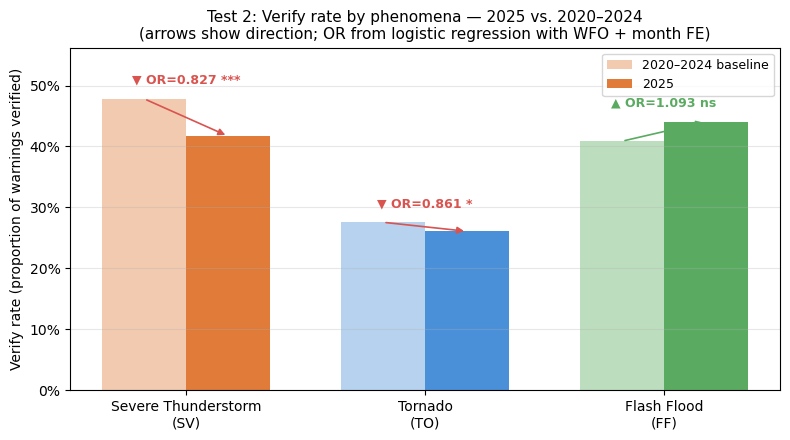

In [5]:
# Test 2 visualization: observed verify rates by phenomena and period
# with regression-adjusted OR annotated

phens = ["SV", "TO", "FF"]

# Compute observed verify rates from raw data
obs = {}
for phen in phens:
    df = conus[
        (conus["phenomena"] == phen) &
        (conus["wfo"].isin(p75_wfos[phen]))
    ]
    obs[phen] = {
        "baseline": df[df["year"] < 2025]["verify"].mean(),
        "2025":     df[df["year"] == 2025]["verify"].mean(),
    }

fig, ax = plt.subplots(figsize=(8, 4.5))

x     = np.arange(len(phens))
width = 0.35

ax.bar(x - width/2, [obs[p]["baseline"] for p in phens],
       width, color=[PHENOMENA_COLORS[p] for p in phens],
       alpha=0.4, label="2020–2024 baseline", edgecolor="none")
ax.bar(x + width/2, [obs[p]["2025"] for p in phens],
       width, color=[PHENOMENA_COLORS[p] for p in phens],
       alpha=1.0, label="2025", edgecolor="none")

for i, phen in enumerate(phens):
    or_, pval = results_t1[phen]["or"], results_t1[phen]["pval"]
    y_top = max(obs[phen]["baseline"], obs[phen]["2025"]) + 0.025
    direction = "▼" if or_ < 1 else "▲"
    color = "#d9534f" if or_ < 1 else "#5aab61"
    ax.annotate(
        f"{direction} OR={or_:.3f} {sig_stars(pval)}",
        xy=(x[i], y_top), ha="center", fontsize=9, color=color, fontweight="bold"
    )
    ax.annotate("",
        xy=(x[i] + width/2, obs[phen]["2025"]),
        xytext=(x[i] - width/2, obs[phen]["baseline"]),
        arrowprops=dict(arrowstyle="-|>", color=color, lw=1.2)
    )

ax.set_xticks(x)
ax.set_xticklabels(["Severe Thunderstorm\n(SV)", "Tornado\n(TO)", "Flash Flood\n(FF)"], fontsize=10)
ax.set_ylabel("Verify rate (proportion of warnings verified)", fontsize=10)
ax.set_title("Test 2: Verify rate by phenomena — 2025 vs. 2020–2024\n"
             "(arrows show direction; OR from logistic regression with WFO + month FE)", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, ax.get_ylim()[1] + 0.06)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "analysis_02_phenomena_verify.png", dpi=150, bbox_inches="tight")
plt.show()

## Test 3 — Volume control: Does the SV FAR increase survive controlling for storm activity?

**Model:** `verify ~ year2025 + log_monthly_events + C(wfo) + C(month)` restricted to top-quartile SV WFOs.

`log_monthly_events` is the log of the number of SV warnings issued by that WFO in that calendar month — a proxy for storm activity. If the 2025 coefficient attenuates to near-zero after controlling for volume, the FAR increase is explained by elevated storm activity (more marginal events). If it persists, it supports the staffing/behavior story.

In [6]:
sv = conus[
    (conus["phenomena"] == "SV") &
    (conus["wfo"].isin(p75_wfos["SV"]))
].copy()
sv["verify_int"] = sv["verify"].astype(int)

# Monthly event count per WFO as storm activity proxy
monthly_vol = (
    sv.groupby(["wfo", "year", "month"])
    .size()
    .reset_index(name="monthly_events")
)
sv = sv.merge(monthly_vol, on=["wfo", "year", "month"], how="left")
sv["log_monthly_events"] = np.log1p(sv["monthly_events"])

# Model without volume control (baseline)
m_base   = smf.logit("verify_int ~ year2025 + C(wfo) + C(month)", data=sv).fit(disp=False, maxiter=200)
# Model with volume control
m_vol    = smf.logit("verify_int ~ year2025 + log_monthly_events + C(wfo) + C(month)", data=sv).fit(disp=False, maxiter=200)

coef_base = m_base.params["year2025"]
coef_vol  = m_vol.params["year2025"]
pval_base = m_base.pvalues["year2025"]
pval_vol  = m_vol.pvalues["year2025"]

print("SV — volume control comparison:")
print(f"  Without volume:  coef={coef_base:+.4f}  OR={np.exp(coef_base):.3f}  p={pval_base:.4f}")
print(f"  With volume:     coef={coef_vol:+.4f}   OR={np.exp(coef_vol):.3f}  p={pval_vol:.4f}")
pct_change = (coef_vol - coef_base) / abs(coef_base) * 100
print(f"  Attenuation: {pct_change:+.1f}% change in year2025 coefficient")
print()
vol_coef = m_vol.params["log_monthly_events"]
vol_pval = m_vol.pvalues["log_monthly_events"]
print(f"  log_monthly_events coef={vol_coef:+.4f}  OR={np.exp(vol_coef):.3f}  p={vol_pval:.4f}")
print("  (Positive OR means more events in a month → more likely to verify, i.e. active months have real storms)")

SV — volume control comparison:
  Without volume:  coef=-0.1895  OR=0.827  p=0.0000
  With volume:     coef=-0.2194   OR=0.803  p=0.0000
  Attenuation: -15.8% change in year2025 coefficient

  log_monthly_events coef=+0.1563  OR=1.169  p=0.0000
  (Positive OR means more events in a month → more likely to verify, i.e. active months have real storms)


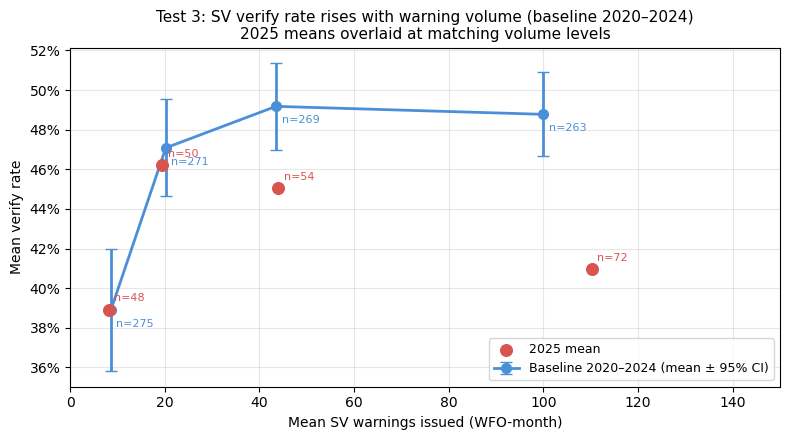

In [7]:
# Test 3 visualization: verify rate vs. warning volume (baseline years only)
# Shows the positive volume-verify relationship that motivates the control variable.

sv_plot = sv.copy()
sv_plot["period"] = np.where(sv_plot["year"] == 2025, "2025", "2020–2024")

monthly = (
    sv_plot.groupby(["wfo", "year", "month", "period"])
    .agg(n_warnings=("verify", "count"), verify_rate=("verify", "mean"))
    .reset_index()
)
monthly = monthly[monthly["n_warnings"] >= 5]

# Bin baseline months into quartiles for better 2025 coverage
base_monthly = monthly[monthly["period"] == "2020–2024"].copy()
base_monthly["vol_bin"], bin_edges = pd.qcut(
    base_monthly["n_warnings"], q=4, retbins=True, duplicates="drop"
)

binned = (
    base_monthly.groupby("vol_bin", observed=True)
    .agg(mean_volume=("n_warnings", "mean"), mean_verify=("verify_rate", "mean"),
         se=("verify_rate", lambda x: x.std() / np.sqrt(len(x))),
         n_baseline=("verify_rate", "count"))
    .reset_index()
)

# Assign 2025 months to the same bins
yr25_monthly = monthly[monthly["period"] == "2025"].copy()
yr25_monthly["vol_bin"] = pd.cut(
    yr25_monthly["n_warnings"], bins=bin_edges, include_lowest=True
)
yr25_binned = (
    yr25_monthly.groupby("vol_bin", observed=True)
    .agg(mean_volume=("n_warnings", "mean"), mean_verify=("verify_rate", "mean"),
         n_2025=("verify_rate", "count"))
    .reset_index()
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(binned["mean_volume"], binned["mean_verify"],
            yerr=binned["se"] * 1.96,
            fmt="o-", color="#4a90d9", linewidth=2, markersize=7,
            capsize=4, label="Baseline 2020–2024 (mean ± 95% CI)")

ax.scatter(yr25_binned["mean_volume"], yr25_binned["mean_verify"],
           color="#d9534f", s=70, zorder=5, label="2025 mean")

# Annotate 2025 dots with sample size
for _, row in yr25_binned.iterrows():
    ax.annotate(f"n={int(row['n_2025'])}",
                xy=(row["mean_volume"], row["mean_verify"]),
                xytext=(4, 6), textcoords="offset points",
                fontsize=8, color="#d9534f")

# Annotate baseline dots with sample size
for _, row in binned.iterrows():
    ax.annotate(f"n={int(row['n_baseline'])}",
                xy=(row["mean_volume"], row["mean_verify"]),
                xytext=(4, -12), textcoords="offset points",
                fontsize=8, color="#4a90d9")

ax.set_xlabel("Mean SV warnings issued (WFO-month)", fontsize=10)
ax.set_ylabel("Mean verify rate", fontsize=10)
ax.set_title("Test 3: SV verify rate rises with warning volume (baseline 2020–2024)\n2025 means overlaid at matching volume levels", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_xlim(left=0, right=150)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "analysis_03_volume_verify.png", dpi=150, bbox_inches="tight")
plt.show()

## Test 4 — Treatment timeline: Interrupted time series

Replace the binary `year2025` indicator with staffing-phase dummies to test whether the signal tracks the known treatment timeline:

| Phase | Period | Event |
|---|---|---|
| `pre` | Jan–Feb 2025 | Pre-termination baseline |
| `post_term` | Mar 2025 | Post-termination, pre-departure |
| `post_dep` | Apr–Jul 2025 | Deferred resignations effective — operationally most significant |
| `post_hire` | Aug–Dec 2025 | Hiring exemption announced — not a recovery |

**Prediction:** The coefficient strengthens in `post_dep` and does not recover in `post_hire`.

All 2020–2024 months serve as the baseline reference.

In [8]:
sv_its = conus[
    (conus["phenomena"] == "SV") &
    (conus["wfo"].isin(p75_wfos["SV"]))
].copy()
sv_its["verify_int"] = sv_its["verify"].astype(int)
sv_its["phase"] = sv_its.apply(phase_label, axis=1)
sv_its["phase"] = pd.Categorical(
    sv_its["phase"],
    categories=["baseline", "pre", "post_term", "post_dep", "post_hire"]
)

model_its  = smf.logit(
    "verify_int ~ C(phase) + C(wfo) + C(month)",
    data=sv_its
)
result_its = model_its.fit(disp=False, maxiter=200)

phase_terms = [c for c in result_its.params.index if "phase" in c]
its_summary = pd.DataFrame({
    "coef": result_its.params[phase_terms],
    "se":   result_its.bse[phase_terms],
    "pval": result_its.pvalues[phase_terms],
    "OR":   np.exp(result_its.params[phase_terms]),
    "OR_lo": np.exp(result_its.conf_int()[0][phase_terms]),
    "OR_hi": np.exp(result_its.conf_int()[1][phase_terms]),
}).round(4)
its_summary.index = [i.replace("C(phase)[T.", "").rstrip("]") for i in its_summary.index]
print("ITS phase coefficients (reference: 2020–2024 baseline):")
print(its_summary.to_string())

ITS phase coefficients (reference: 2020–2024 baseline):
             coef      se    pval      OR   OR_lo   OR_hi
pre       -0.1495  0.1777  0.4003  0.8612  0.6078  1.2200
post_term  0.1642  0.0756  0.0298  1.1785  1.0163  1.3666
post_dep  -0.2267  0.0261  0.0000  0.7972  0.7574  0.8391
post_hire -0.2133  0.0517  0.0000  0.8079  0.7300  0.8941


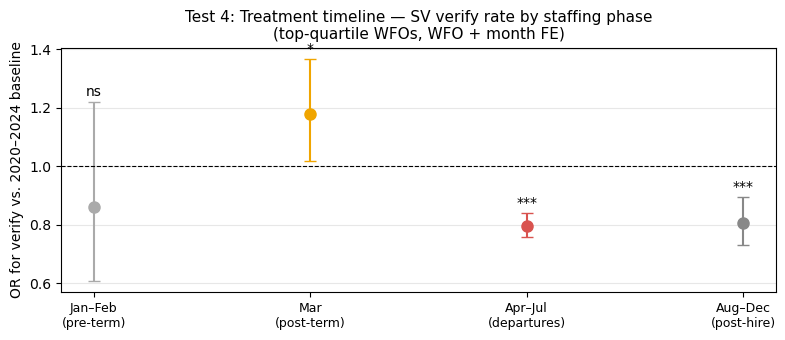

In [9]:
# ITS forest plot
phase_labels = ["pre", "post_term", "post_dep", "post_hire"]
phase_display = ["Jan–Feb\n(pre-term)", "Mar\n(post-term)", "Apr–Jul\n(departures)", "Aug–Dec\n(post-hire)"]
colors_its = ["#aaaaaa", "#f0a500", "#d9534f", "#888888"]

fig, ax = plt.subplots(figsize=(8, 3.5))
for i, (phase, disp, col) in enumerate(zip(phase_labels, phase_display, colors_its)):
    if phase not in its_summary.index:
        continue
    row = its_summary.loc[phase]
    ax.errorbar(
        i, row["OR"],
        yerr=[[row["OR"] - row["OR_lo"]], [row["OR_hi"] - row["OR"]]],
        fmt="o", color=col, markersize=8, capsize=4, linewidth=1.5
    )
    sig = "***" if row["pval"] < 0.001 else "**" if row["pval"] < 0.01 else "*" if row["pval"] < 0.05 else "ns"
    ax.text(i, row["OR_hi"] + 0.01, sig, ha="center", va="bottom", fontsize=10)

ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(phase_labels)))
ax.set_xticklabels(phase_display, fontsize=9)
ax.set_ylabel("OR for verify vs. 2020–2024 baseline", fontsize=10)
ax.set_title("Test 4: Treatment timeline — SV verify rate by staffing phase\n(top-quartile WFOs, WFO + month FE)", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "analysis_04_its_phases.png", dpi=150, bbox_inches="tight")
plt.show()

## Test 5 — Co-occurrence / triage test

**Hypothesis:** If forecasters were triaging under resource pressure, SV warnings issued on days with concurrent TO or FF activity should show a larger verify-rate drop in 2025 than SV warnings issued on low-triage days.

**Operationalization:** For each SV warning, flag `high_triage=True` if the same WFO issued at least one TO or FF warning within ±3 hours of the SV issuance time. Then test the interaction `year2025 × high_triage`.

**Prediction:** The `year2025 × high_triage` interaction coefficient is negative and significant — the 2025 SV verify rate drops more on days when the forecaster was simultaneously managing TO/FF warnings.

In [10]:
TRIAGE_WINDOW_HRS = 3

to_ff = conus[conus["phenomena"].isin(["TO", "FF"])][["wfo", "issue"]].copy()
to_ff["issue"] = pd.to_datetime(to_ff["issue"], utc=True)
to_ff = to_ff.rename(columns={"issue": "toFF_issue"})

sv_triage = conus[
    (conus["phenomena"] == "SV") &
    (conus["wfo"].isin(p75_wfos["SV"]))
].copy().reset_index(drop=True)
sv_triage["issue"] = pd.to_datetime(sv_triage["issue"], utc=True)
sv_triage["verify_int"] = sv_triage["verify"].astype(int)

sv_triage["high_triage_direct"] = sv_triage["svr_tornado_possible"].fillna(False).astype(bool)

# Vectorized ±window join using a clean 0-based index as the join key
window = pd.Timedelta(hours=TRIAGE_WINDOW_HRS)
sv_keyed = sv_triage[["wfo", "issue"]].copy()
sv_keyed["sv_idx"] = sv_keyed.index

merged = sv_keyed.merge(to_ff, on="wfo", how="left")
merged["within_window"] = (merged["toFF_issue"] - merged["issue"]).abs() <= window
hit = merged.groupby("sv_idx")["within_window"].any()
sv_triage["high_triage_window"] = hit.reindex(sv_triage.index, fill_value=False)

sv_triage["high_triage_window_int"] = sv_triage["high_triage_window"].astype(int)
sv_triage["high_triage_direct_int"] = sv_triage["high_triage_direct"].astype(int)

print(f"SV events with high_triage_direct (svr_tornado_possible): {sv_triage['high_triage_direct'].sum():,} ({sv_triage['high_triage_direct'].mean():.1%})")
print(f"SV events with high_triage_window (±{TRIAGE_WINDOW_HRS}hr TO/FF): {sv_triage['high_triage_window'].sum():,} ({sv_triage['high_triage_window'].mean():.1%})")

SV events with high_triage_direct (svr_tornado_possible): 5,588 (9.6%)
SV events with high_triage_window (±3hr TO/FF): 28,931 (49.8%)


In [11]:
def triage_model(df, triage_col, label):
    m = smf.logit(
        f"verify_int ~ year2025 * {triage_col} + C(wfo) + C(month)",
        data=df
    ).fit(disp=False, maxiter=200)

    terms = ["year2025", triage_col, f"year2025:{triage_col}"]
    out = pd.DataFrame({
        "coef": m.params[terms],
        "se":   m.bse[terms],
        "pval": m.pvalues[terms],
        "OR":   np.exp(m.params[terms]),
    }).round(4)
    print(f"\n--- {label} ---")
    print(out.to_string())
    return m

m_direct = triage_model(sv_triage, "high_triage_direct_int", "svr_tornado_possible (direct flag)")
m_window = triage_model(sv_triage, "high_triage_window_int", f"±{TRIAGE_WINDOW_HRS}hr TO/FF window")


--- svr_tornado_possible (direct flag) ---
                                   coef      se    pval      OR
year2025                        -0.1885  0.0233  0.0000  0.8282
high_triage_direct_int           0.1521  0.0346  0.0000  1.1643
year2025:high_triage_direct_int -0.0307  0.0713  0.6672  0.9698

--- ±3hr TO/FF window ---
                                   coef      se    pval      OR
year2025                        -0.1956  0.0323  0.0000  0.8224
high_triage_window_int           0.2255  0.0203  0.0000  1.2529
year2025:high_triage_window_int -0.0095  0.0441  0.8297  0.9905


## Test 6 — Overnight closure dose-response (negative result)

From EDA, offices that lost 24/7 operations (GLD, JKL, HNX, STO, CYS, PAH, MQT) did **not** show excess SV verify-rate degradation relative to the top-quartile WFO median. This test formalizes that finding: add an `overnight_closed` indicator and its interaction with `year2025` to the SV regression. A null or positive interaction confirms the EDA finding that compensatory staffing worked at named/visible offices — degradation is diffuse across offices with moderate vacancy rates.

In [12]:
sv_closure = conus[
    (conus["phenomena"] == "SV") &
    (conus["wfo"].isin(p75_wfos["SV"]))
].copy()
sv_closure["verify_int"]      = sv_closure["verify"].astype(int)
sv_closure["overnight_closed"] = sv_closure["wfo"].isin(OVERNIGHT_CLOSED).astype(int)

closed_in_set = p75_wfos["SV"] & OVERNIGHT_CLOSED
print(f"Overnight-closed offices in top-quartile SV set: {sorted(closed_in_set)}")
print(f"Events from closure offices: {sv_closure['overnight_closed'].sum():,} ({sv_closure['overnight_closed'].mean():.1%})")

m_closure = smf.logit(
    "verify_int ~ year2025 * overnight_closed + C(wfo) + C(month)",
    data=sv_closure
).fit(disp=False, maxiter=200)

terms = ["year2025", "overnight_closed", "year2025:overnight_closed"]
out = pd.DataFrame({
    "coef": m_closure.params[terms],
    "se":   m_closure.bse[terms],
    "pval": m_closure.pvalues[terms],
    "OR":   np.exp(m_closure.params[terms]),
}).round(4)
print("\nOvernight closure interaction:")
print(out.to_string())
print()
print("Null/positive interaction = closure offices did not drive excess degradation")
print("(compensatory staffing worked at named offices; degradation is diffuse)")

Overnight-closed offices in top-quartile SV set: ['GLD', 'PAH']
Events from closure offices: 3,657 (6.3%)

Overnight closure interaction:
                             coef      se    pval      OR
year2025                  -0.1907  0.0225  0.0000  0.8263
overnight_closed           0.7328     NaN     NaN  2.0808
year2025:overnight_closed  0.0172  0.0697  0.8049  1.0174

Null/positive interaction = closure offices did not drive excess degradation
(compensatory staffing worked at named offices; degradation is diffuse)


## Test 7 — Sensitivity checks

Three robustness checks on the primary SV result:

1. **All-CONUS vs. top-quartile:** Does the result hold when including all CONUS WFOs, not just the high-volume subset?
2. **Alternate treatment dates:** Feb 27 (terminations) vs. Apr 1 (departures effective) as the treatment start — does the result depend on which month we call "2025 treated"?
3. **lead0 exclusions:** Does the lead time distribution change in 2025 after excluding `lead0=0` events (minute-resolution artifact) and `lead0_capped` events?

In [13]:
# --- 7a. All-CONUS vs top-quartile ---
print("=== 7a. All-CONUS vs. top-quartile ===\n")

all_sv = conus[conus["phenomena"] == "SV"].copy()
all_sv["verify_int"] = all_sv["verify"].astype(int)

m_all = smf.logit(
    "verify_int ~ year2025 + C(wfo) + C(month)", data=all_sv
).fit(disp=False, maxiter=200)

for label, m in [("top-quartile (29 WFOs)", results_t1["SV"]["result"]),
                 ("all-CONUS", m_all)]:
    c = m.params["year2025"]
    p = m.pvalues["year2025"]
    print(f"  {label:28s}  coef={c:+.4f}  OR={np.exp(c):.3f}  p={p:.4f}")

=== 7a. All-CONUS vs. top-quartile ===

  top-quartile (29 WFOs)        coef=-0.1895  OR=0.827  p=0.0000
  all-CONUS                     coef=-0.1695  OR=0.844  p=0.0000


In [14]:
# --- 7b. Alternate treatment date ---
print("=== 7b. Alternate treatment date (Apr 2025 vs. full-year 2025) ===\n")

sv_alt = conus[
    (conus["phenomena"] == "SV") &
    (conus["wfo"].isin(p75_wfos["SV"]))
].copy()
sv_alt["verify_int"] = sv_alt["verify"].astype(int)

# Apr 1 treatment: only Apr–Dec 2025 are "treated"; Jan–Mar 2025 are baseline
sv_alt["year2025_apr"] = (
    (sv_alt["year"] == 2025) & (sv_alt["month"] >= 4)
).astype(int)

# Exclude Jan–Mar 2025 entirely for a clean pre/post Apr cut
sv_clean = sv_alt[~((sv_alt["year"] == 2025) & (sv_alt["month"] < 4))].copy()

m_apr = smf.logit(
    "verify_int ~ year2025_apr + C(wfo) + C(month)", data=sv_clean
).fit(disp=False, maxiter=200)

for label, m, col in [
    ("full 2025 (Jan cut)",  results_t1["SV"]["result"], "year2025"),
    ("Apr+ 2025 (Apr cut)",  m_apr,                      "year2025_apr"),
]:
    c = m.params[col]
    p = m.pvalues[col]
    print(f"  {label:28s}  coef={c:+.4f}  OR={np.exp(c):.3f}  p={p:.4f}")

=== 7b. Alternate treatment date (Apr 2025 vs. full-year 2025) ===

  full 2025 (Jan cut)           coef=-0.1895  OR=0.827  p=0.0000
  Apr+ 2025 (Apr cut)           coef=-0.2238  OR=0.800  p=0.0000


In [15]:
# --- 7c. Lead time sensitivity ---
print("=== 7c. Lead time distribution — exclusion sensitivity ===\n")

sv_verified = conus[
    (conus["phenomena"] == "SV") &
    (conus["wfo"].isin(p75_wfos["SV"])) &
    (conus["verify"] == True)
].copy()

sv_verified["period"] = np.where(sv_verified["year"] == 2025, "2025", "2020–2024")

def lead_summary(df, label):
    g = df.groupby("period")["lead0"].agg(["median", "mean", "count"])
    print(f"  {label}")
    print(g.to_string())
    print()

lead_summary(sv_verified, "All verified SV (baseline)")
lead_summary(sv_verified[sv_verified["lead0"] > 0], "Exclude lead0=0 (minute-resolution artifact)")
lead_summary(sv_verified[~sv_verified["lead0_capped"]], "Exclude lead0_capped events")
lead_summary(
    sv_verified[(sv_verified["lead0"] > 0) & (~sv_verified["lead0_capped"])],
    "Exclude both lead0=0 and lead0_capped"
)

=== 7c. Lead time distribution — exclusion sensitivity ===

  All verified SV (baseline)
           median       mean  count
period                             
2020–2024    11.0  14.695568  22133
2025         11.0  14.804246   4899

  Exclude lead0=0 (minute-resolution artifact)
           median       mean  count
period                             
2020–2024    12.0  15.587147  20867
2025         13.0  15.818103   4585

  Exclude lead0_capped events
           median       mean  count
period                             
2020–2024    11.0  14.261503  21885
2025         11.0  14.386504   4846

  Exclude both lead0=0 and lead0_capped
           median       mean  count
period                             
2020–2024    12.0  15.137155  20619
2025         12.0  15.383274   4532



### 7d. Warning characteristics: Did SV issuance methods change in 2025?

A uniform FAR increase could reflect changed NWS guidance or protocols rather than staffing effects — e.g., lower hail/wind thresholds, larger warning polygons, or more precautionary issuing. Compare the distribution of `hailtag`, `windtag`, `carea`, and `sharedborder` between 2025 and the 2020–2024 baseline for top-quartile SV WFOs.

If distributions are stable, the methods-change alternative explanation is undermined. If they shifted (lower thresholds, larger polygons), that needs to be acknowledged.

=== 7d. SV Warning characteristics: 2025 vs. 2020–2024 ===

Hail tag (inches)
  baseline median=1.00  2025 median=1.00  Δ=+0.0%  MW p=0.0254 *

Wind tag (knots)
  baseline median=60.00  2025 median=60.00  Δ=+0.0%  MW p=0.9765 ns

Warning area (km²)
  baseline median=5265.79  2025 median=5795.30  Δ=+10.1%  MW p=0.0000 ***

Shared border (km)
  baseline median=33628.24  2025 median=31682.62  Δ=-5.8%  MW p=0.0008 ***



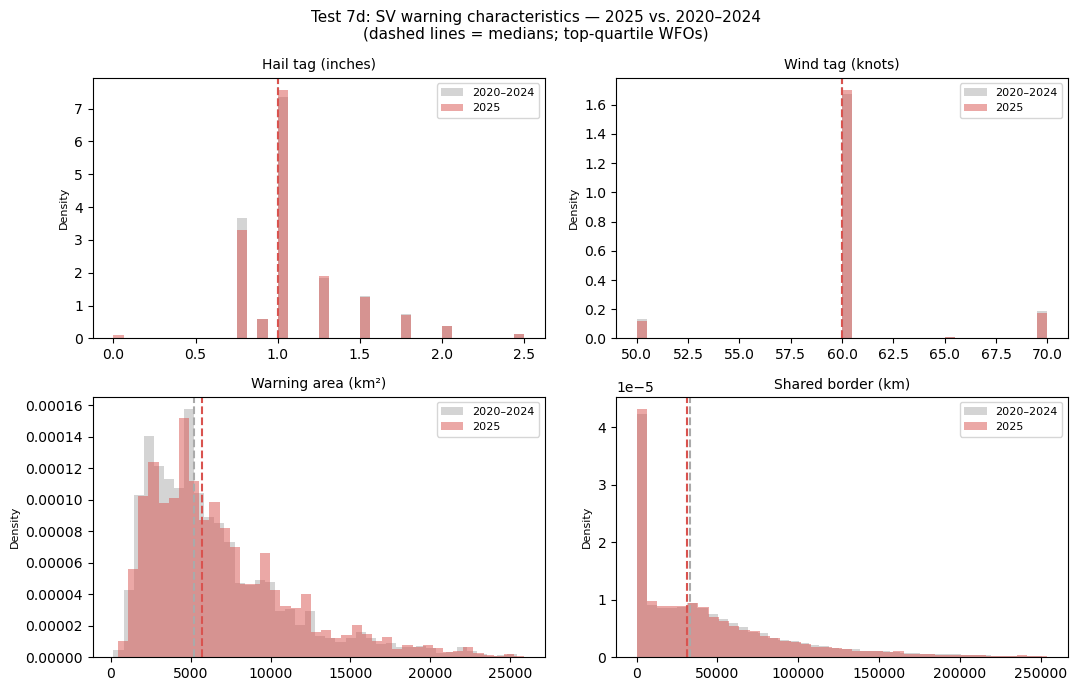

In [16]:
sv_chars = conus[
    (conus["phenomena"] == "SV") &
    (conus["wfo"].isin(p75_wfos["SV"]))
].copy()
sv_chars["period"] = np.where(sv_chars["year"] == 2025, "2025", "2020–2024")

# --- Numeric tag fields: parse hailtag/windtag to float ---
sv_chars["hailtag_f"] = pd.to_numeric(sv_chars["hailtag"], errors="coerce")
sv_chars["windtag_f"] = pd.to_numeric(sv_chars["windtag"], errors="coerce")

print("=== 7d. SV Warning characteristics: 2025 vs. 2020–2024 ===\n")

numeric_cols = {
    "hailtag_f":    "Hail tag (inches)",
    "windtag_f":    "Wind tag (knots)",
    "carea":        "Warning area (km²)",
    "sharedborder": "Shared border (km)",
}

rows_chars = []
for col, label in numeric_cols.items():
    grp = sv_chars.groupby("period")[col].agg(["median", "mean", "count"])
    base = grp.loc["2020–2024"]
    yr25 = grp.loc["2025"]
    pct  = (yr25["median"] - base["median"]) / base["median"] * 100 if base["median"] != 0 else np.nan

    # Mann-Whitney U test (non-parametric; doesn't assume normality)
    a = sv_chars[sv_chars["period"] == "2020–2024"][col].dropna()
    b = sv_chars[sv_chars["period"] == "2025"][col].dropna()
    stat, pval = stats.mannwhitneyu(a, b, alternative="two-sided") if len(b) > 0 else (np.nan, np.nan)

    rows_chars.append({
        "Field": label,
        "Baseline median": f"{base['median']:.2f}",
        "2025 median":     f"{yr25['median']:.2f}",
        "Δ median %":      f"{pct:+.1f}%",
        "MW p-value":      f"{pval:.4f}",
        "Sig":             sig_stars(pval),
    })
    print(f"{label}")
    print(f"  baseline median={base['median']:.2f}  2025 median={yr25['median']:.2f}  Δ={pct:+.1f}%  MW p={pval:.4f} {sig_stars(pval)}")
    print()

chars_df = pd.DataFrame(rows_chars)

# --- Visual: distribution shift plots ---
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()
plot_cols = ["hailtag_f", "windtag_f", "carea", "sharedborder"]
plot_labels = ["Hail tag (inches)", "Wind tag (knots)", "Warning area (km²)", "Shared border (km)"]
colors_period = {"2020–2024": "#aaaaaa", "2025": "#d9534f"}

for ax, col, label in zip(axes, plot_cols, plot_labels):
    for period, color in colors_period.items():
        vals = sv_chars[sv_chars["period"] == period][col].dropna()
        # Cap at 99th percentile for display
        cap = vals.quantile(0.99)
        vals = vals[vals <= cap]
        ax.hist(vals, bins=40, alpha=0.5, color=color, label=period, density=True)
        ax.axvline(vals.median(), color=color, linewidth=1.5, linestyle="--")
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel("Density", fontsize=8)

fig.suptitle("Test 7d: SV warning characteristics — 2025 vs. 2020–2024\n(dashed lines = medians; top-quartile WFOs)", fontsize=11)
plt.tight_layout()
plt.savefig(IMG_DIR / "analysis_07d_warning_characteristics.png", dpi=150, bbox_inches="tight")
plt.show()

### 7e. Polygon area control: Does the year2025 effect survive controlling for warning size?

Warning polygon area increased +10.1% in 2025. Larger polygons may verify at lower rates mechanically (the storm report must fall inside the polygon). Adding `log(carea)` as a covariate tests whether the year2025 coefficient attenuates after accounting for polygon size.

- **Attenuation to near-zero** → polygon area explains the verify rate drop; methods change is a plausible alternative
- **Persistence** → the 2025 effect is not explained by polygon size alone

In [17]:
print("=== 7e. Polygon area control ===\n")

sv_area = conus[
    (conus["phenomena"] == "SV") &
    (conus["wfo"].isin(p75_wfos["SV"])) &
    (conus["carea"].notna()) &
    (conus["carea"] > 0)
].copy()
sv_area["verify_int"]  = sv_area["verify"].astype(int)
sv_area["log_carea"]   = np.log(sv_area["carea"])

m_no_area = smf.logit(
    "verify_int ~ year2025 + C(wfo) + C(month)", data=sv_area
).fit(disp=False, maxiter=200)

m_area = smf.logit(
    "verify_int ~ year2025 + log_carea + C(wfo) + C(month)", data=sv_area
).fit(disp=False, maxiter=200)

coef_no  = m_no_area.params["year2025"]
coef_yes = m_area.params["year2025"]
pval_no  = m_no_area.pvalues["year2025"]
pval_yes = m_area.pvalues["year2025"]
pct_atten = (coef_yes - coef_no) / abs(coef_no) * 100

print(f"  Without area control:  coef={coef_no:+.4f}  OR={np.exp(coef_no):.3f}  p={pval_no:.4f}")
print(f"  With log(carea):       coef={coef_yes:+.4f}  OR={np.exp(coef_yes):.3f}  p={pval_yes:.4f}")
print(f"  Attenuation: {pct_atten:+.1f}% change in year2025 coefficient")
print()

area_coef = m_area.params["log_carea"]
area_pval = m_area.pvalues["log_carea"]
print(f"  log_carea coef={area_coef:+.4f}  OR={np.exp(area_coef):.3f}  p={area_pval:.4f}")
print("  (Negative OR expected: larger polygon → lower verify rate)")
print()
print(f"  n with valid carea: {len(sv_area):,} of {sv_chars['wfo'].isin(p75_wfos['SV']).sum():,} total SV events")

=== 7e. Polygon area control ===

  Without area control:  coef=-0.1895  OR=0.827  p=0.0000
  With log(carea):       coef=-0.2107  OR=0.810  p=0.0000
  Attenuation: -11.2% change in year2025 coefficient

  log_carea coef=+0.4982  OR=1.646  p=0.0000
  (Negative OR expected: larger polygon → lower verify rate)

  n with valid carea: 58,042 of 58,042 total SV events


## Results Summary

Consolidated table of all primary test outcomes for the paper.

In [18]:
rows = []
for phen in ["SV", "TO", "FF"]:
    r = results_t1[phen]
    rows.append({
        "Test": "1 — Primary logit",
        "Phenomena": phen,
        "Scope": "top-quartile",
        "OR": f"{r['or']:.3f}",
        "95% CI": f"[{r['or_lo']:.3f}, {r['or_hi']:.3f}]",
        "p": f"{r['pval']:.4f}",
        "Sig": sig_stars(r["pval"]),
    })

# Test 2 interaction
for term, phen in [("year2025", "SV baseline"),
                   ("year2025:C(phenomena)[T.TO]", "TO vs SV interaction"),
                   ("year2025:C(phenomena)[T.FF]", "FF vs SV interaction")]:
    c = result_t2.params[term]
    p = result_t2.pvalues[term]
    ci = result_t2.conf_int().loc[term]
    rows.append({
        "Test": "2 — Interaction",
        "Phenomena": phen,
        "Scope": "pooled",
        "OR": f"{np.exp(c):.3f}",
        "95% CI": f"[{np.exp(ci[0]):.3f}, {np.exp(ci[1]):.3f}]",
        "p": f"{p:.4f}",
        "Sig": sig_stars(p),
    })

# Test 3
for label, m, col in [("no vol ctrl", m_base, "year2025"), ("with vol ctrl", m_vol, "year2025")]:
    c = m.params[col]; p = m.pvalues[col]; ci = m.conf_int().loc[col]
    rows.append({
        "Test": "3 — Volume ctrl",
        "Phenomena": f"SV ({label})",
        "Scope": "top-quartile",
        "OR": f"{np.exp(c):.3f}",
        "95% CI": f"[{np.exp(ci[0]):.3f}, {np.exp(ci[1]):.3f}]",
        "p": f"{p:.4f}",
        "Sig": sig_stars(p),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

             Test            Phenomena        Scope    OR         95% CI      p Sig
1 — Primary logit                   SV top-quartile 0.827 [0.792, 0.864] 0.0000 ***
1 — Primary logit                   TO top-quartile 0.861 [0.755, 0.980] 0.0238   *
1 — Primary logit                   FF top-quartile 1.093 [0.996, 1.200] 0.0597  ns
  2 — Interaction          SV baseline       pooled 0.825 [0.791, 0.861] 0.0000 ***
  2 — Interaction TO vs SV interaction       pooled 1.112 [0.975, 1.269] 0.1141  ns
  2 — Interaction FF vs SV interaction       pooled 1.345 [1.218, 1.486] 0.0000 ***
  3 — Volume ctrl     SV (no vol ctrl) top-quartile 0.827 [0.792, 0.864] 0.0000 ***
  3 — Volume ctrl   SV (with vol ctrl) top-quartile 0.803 [0.769, 0.839] 0.0000 ***


## Test 8 — County-level warning coverage: Did service quality change in 2025?

**Motivation:** All prior tests aggregate performance to the WFO level. This test asks the resident-facing question: *as a person living in a specific county, did the quality of NWS warning service change in 2025?*

**Two resident-facing metrics per county × phenomena × year:**

- **Warning verify rate** — of warnings issued for this county, what fraction were verified by any LSR? Measures whether warnings covering this county were meaningful.
- **LSR warned fraction** — of confirmed hazardous events reported in this county, what fraction had a warning in effect? Measures whether real events in this county were covered.

**Construction:**
- Warning side: `events_ugc` joined to `events` on `product_id` — gives county footprint and verify status of every warning
- LSR side: `stormreports` grouped by `county` + `state` — gives confirmed events per county (excluding `tdq=True`)
- Match key: `COUNTY|STATE` normalized to uppercase; 99.56% of LSR rows match a county in `events_ugc`

**Volume filter:** Counties with fewer than 10 LSRs total over the 2020–2024 baseline are excluded — too sparse for reliable annual estimates.

**Known limitations:**
- A warning covering six counties counts as one verified warning for each of them, even if the confirming LSR came from only one. This inflates verify rates for large-polygon warnings, particularly SV. Results should be interpreted with this in mind.
- Unwarned LSRs are assigned to the county in the stormreports text field, which is observer-reported, not instrumentally determined. A storm that occurred but was not reported does not appear.
- These limitations apply equally across years; they do not introduce directional bias into the 2025 vs. baseline comparison unless reporting behavior or polygon size changed systematically — which Test 7d examined.

**Interpretation:** Results are offered as **hypothesis-generating**, not confirmatory. The aggregate statistics establish that a real but modest national shift occurred; the county-level maps identify specific locations where the shift was large enough to warrant closer investigation by researchers with access to richer data — staffing records, vacancy rates, overtime logs — not available in this dataset.

**Geographic clusters visible in the SV warning verify rate map that merit follow-up:**
- A coherent band of degraded verify rates running through the Dakotas, Nebraska, Kansas, and Oklahoma — the rural Plains corridor where WFO staffing pressure has been most publicly documented and spotter network density is lowest
- A cluster of counties in Alabama
- A cluster of counties in Georgia

These clusters are not asserted to be causally linked to staffing cuts. They are candidate areas for investigators who can obtain WFO-level staffing data to test whether the geographic pattern of verify rate degradation tracks the geographic pattern of vacancy rates.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from src.analysis.constants import PHENOMENA_LABELS, PHENOMENA_COLORS, NON_CONUS

CLEAN_DIR = Path("../data/03_cleaning")
MIN_BASELINE_LSRS = 10  # minimum LSRs over 2020-2024 to include a county

# ── Load events_ugc and join to events ───────────────────────────────────
ugc = pd.read_csv(CLEAN_DIR / "events_ugc.csv")

ev = pd.read_csv(CLEAN_DIR / "events.csv")
ev = ev[~ev["wfo"].isin(NON_CONUS)]

# Drop columns from ugc that also exist in events to avoid _x/_y suffixes
warn_county = ugc.drop(columns=["wfo", "year", "phenomena"]).merge(
    ev[["product_id", "year", "phenomena", "verify"]],
    on="product_id", how="inner"
)
warn_county["county_key"] = (
    warn_county["ugc_name"].str.replace(r"\s+[A-Z]{2}$", "", regex=True)
    .str.strip().str.upper()
    + "|" + warn_county["state_code"].str.strip().str.upper()
)

# ── Load stormreports ─────────────────────────────────────────────────────
sr = pd.read_csv(CLEAN_DIR / "stormreports.csv")
sr = sr[~sr["tdq"]]  # exclude unconfirmed events
sr = sr[~sr["wfo"].isin(NON_CONUS)]
sr["county_key"] = (
    sr["county"].astype(str).str.strip().str.upper()
    + "|" + sr["state"].astype(str).str.strip().str.upper()
)

# ── County-level aggregation ──────────────────────────────────────────────
# Warning verify rate: per county × phenomena × year
warn_yr = (
    warn_county
    .groupby(["county_key", "phenomena", "year"])
    .agg(n_warnings=("verify", "count"), n_verified=("verify", "sum"))
    .reset_index()
    .assign(verify_rate=lambda d: d["n_verified"] / d["n_warnings"])
)

# LSR warned fraction: per county × lsrtype × year
lsr_yr = (
    sr
    .groupby(["county_key", "lsrtype", "year"])
    .agg(n_lsrs=("warned", "count"), n_warned=("warned", "sum"))
    .reset_index()
    .rename(columns={"lsrtype": "phenomena"})
    .assign(warned_frac=lambda d: d["n_warned"] / d["n_lsrs"])
)

# ── Volume filter: keep counties with >= MIN_BASELINE_LSRS over 2020-2024 ─
baseline_lsr_vol = (
    lsr_yr[lsr_yr["year"] <= 2024]
    .groupby(["county_key", "phenomena"])["n_lsrs"]
    .sum()
    .reset_index(name="baseline_lsr_total")
)
eligible = baseline_lsr_vol[
    baseline_lsr_vol["baseline_lsr_total"] >= MIN_BASELINE_LSRS
][["county_key", "phenomena"]]

warn_yr = warn_yr.merge(eligible, on=["county_key", "phenomena"], how="inner")
lsr_yr  = lsr_yr.merge(eligible,  on=["county_key", "phenomena"], how="inner")

print(f"Eligible counties (≥{MIN_BASELINE_LSRS} baseline LSRs) by phenomena:")
for phen in ["TO", "SV", "FF"]:
    n = eligible[eligible["phenomena"] == phen]["county_key"].nunique()
    print(f"  {PHENOMENA_LABELS[phen]:<25} {n:,} counties")

# ── Compute per-county deltas: 2025 vs. baseline mean ────────────────────
def county_deltas(df, metric):
    base = (
        df[df["year"] <= 2024]
        .groupby(["county_key", "phenomena"])[metric]
        .mean()
        .reset_index(name="baseline_mean")
    )
    yr25 = (
        df[df["year"] == 2025]
        [["county_key", "phenomena", metric]]
        .rename(columns={metric: "val_2025"})
    )
    merged = base.merge(yr25, on=["county_key", "phenomena"], how="inner")
    merged["delta"] = merged["val_2025"] - merged["baseline_mean"]
    return merged

warn_delta = county_deltas(warn_yr,  "verify_rate")
lsr_delta  = county_deltas(lsr_yr,   "warned_frac")

# ── Summary table ─────────────────────────────────────────────────────────
print(f"\n{'Phenomena':<25} {'Metric':<25} {'n counties':>10} "
      f"{'Median Δ':>10} {'% worse':>8}")
print("─" * 82)
for phen in ["TO", "SV", "FF"]:
    for label, df in [("Warning verify rate", warn_delta),
                      ("LSR warned fraction",  lsr_delta)]:
        sub = df[df["phenomena"] == phen]
        if len(sub) == 0:
            continue
        med   = sub["delta"].median()
        worse = (sub["delta"] < 0).mean()
        print(f"  {PHENOMENA_LABELS[phen]:<23} {label:<25} {len(sub):>10} "
              f"{med:>+10.3f} {worse:>8.1%}")

Eligible counties (≥10 baseline LSRs) by phenomena:
  Tornado                   220 counties
  Severe Thunderstorm       2,773 counties
  Flash Flood               729 counties

Phenomena                 Metric                    n counties   Median Δ  % worse
──────────────────────────────────────────────────────────────────────────────────
  Tornado                 Warning verify rate              194     -0.057    56.7%
  Tornado                 LSR warned fraction              126     +0.081    34.9%
  Severe Thunderstorm     Warning verify rate             2743     -0.023    56.3%
  Severe Thunderstorm     LSR warned fraction             2622     +0.055    37.4%
  Flash Flood             Warning verify rate              646     +0.006    47.2%
  Flash Flood             LSR warned fraction              558     +0.036    33.3%


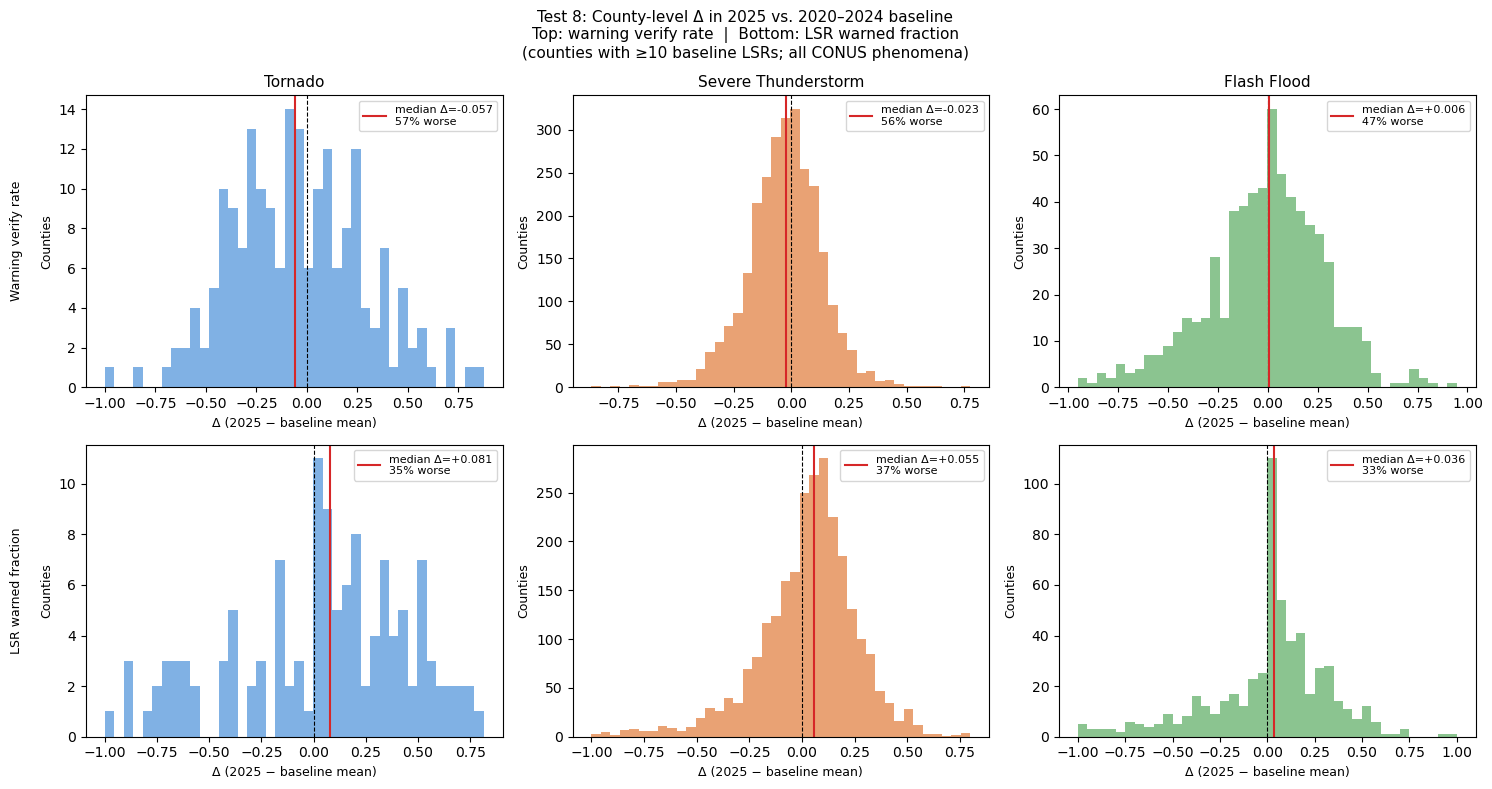


Phenomena                 Metric                         n   Median Δ   Wilcoxon p   Sig
─────────────────────────────────────────────────────────────────────────────────────
  Tornado                 Warning verify rate          194     -0.057       0.0463     *
  Tornado                 LSR warned fraction          126     +0.081       0.1290    ns
  Severe Thunderstorm     Warning verify rate         2743     -0.023       0.0000   ***
  Severe Thunderstorm     LSR warned fraction         2622     +0.055       0.0000   ***
  Flash Flood             Warning verify rate          646     +0.006       0.9061    ns
  Flash Flood             LSR warned fraction          558     +0.036       0.0044    **


In [20]:
# ── Delta distributions: one panel per phenomena × metric ────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)

for col, phen in enumerate(["TO", "SV", "FF"]):
    for row, (label, df) in enumerate([
        ("Warning verify rate", warn_delta),
        ("LSR warned fraction",  lsr_delta),
    ]):
        ax = axes[row, col]
        sub = df[df["phenomena"] == phen]["delta"].dropna()
        if len(sub) == 0:
            ax.set_visible(False)
            continue

        med   = sub.median()
        worse = (sub < 0).mean()
        color = PHENOMENA_COLORS[phen]

        ax.hist(sub, bins=40, color=color, alpha=0.7, edgecolor="none")
        ax.axvline(0,   color="black", linewidth=0.8, linestyle="--")
        ax.axvline(med, color="#d62728", linewidth=1.5,
                   label=f"median Δ={med:+.3f}\n{worse:.0%} worse")
        ax.set_xlabel("Δ (2025 − baseline mean)", fontsize=9)
        ax.set_ylabel("Counties", fontsize=9)
        ax.legend(fontsize=8)
        if row == 0:
            ax.set_title(PHENOMENA_LABELS[phen], fontsize=11)
        if col == 0:
            ax.set_ylabel(f"{label}\n\nCounties", fontsize=9)

fig.suptitle("Test 8: County-level Δ in 2025 vs. 2020–2024 baseline\n"
             "Top: warning verify rate  |  Bottom: LSR warned fraction\n"
             f"(counties with ≥{MIN_BASELINE_LSRS} baseline LSRs; all CONUS phenomena)",
             fontsize=11)
plt.tight_layout()
plt.savefig(IMG_DIR / "analysis_08_county_deltas.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Wilcoxon signed-rank test: is the median delta != 0? ─────────────────
from scipy import stats

print(f"\n{'Phenomena':<25} {'Metric':<25} {'n':>6} {'Median Δ':>10} "
      f"{'Wilcoxon p':>12} {'Sig':>5}")
print("─" * 85)
for phen in ["TO", "SV", "FF"]:
    for label, df in [("Warning verify rate", warn_delta),
                      ("LSR warned fraction",  lsr_delta)]:
        sub = df[df["phenomena"] == phen]["delta"].dropna()
        if len(sub) < 10:
            continue
        stat, p = stats.wilcoxon(sub, alternative="two-sided")
        print(f"  {PHENOMENA_LABELS[phen]:<23} {label:<25} {len(sub):>6} "
              f"{sub.median():>+10.3f} {p:>12.4f} {sig_stars(p):>5}")

warn_delta rows with geometry: 3,572 of 3,583
lsr_delta  rows with geometry: 3,287 of 3,306


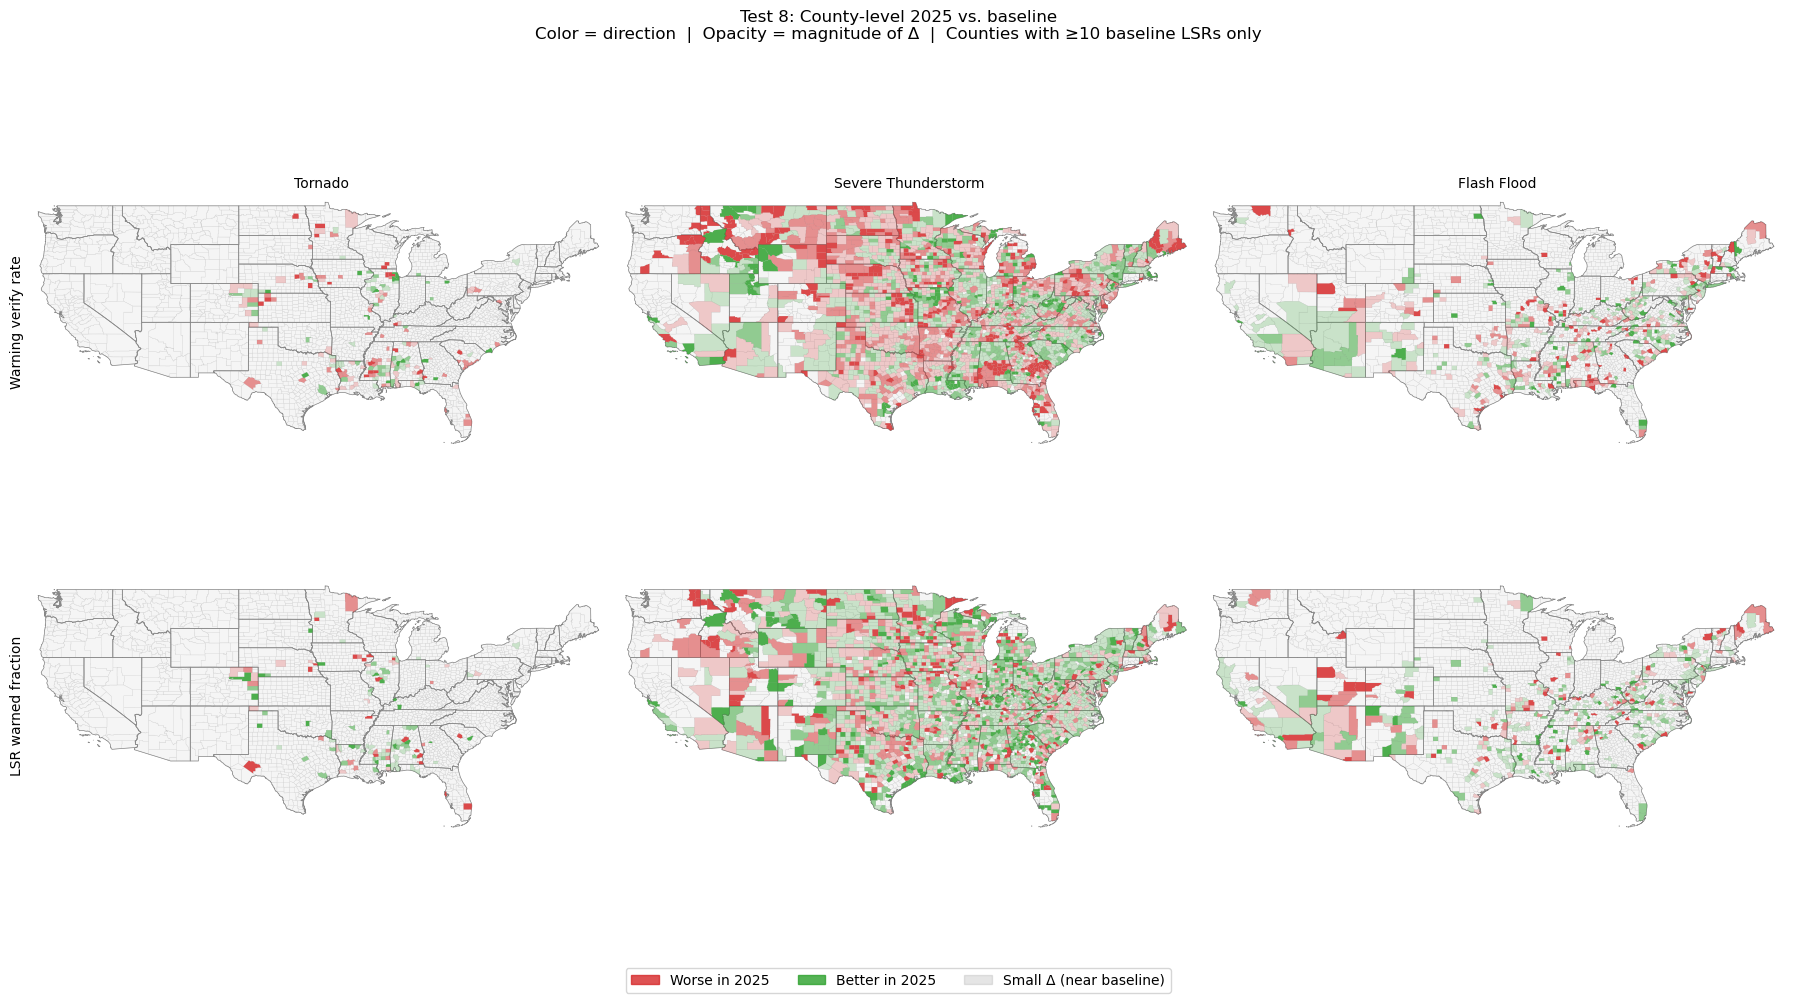

In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from src.analysis.constants import CONUS_XLIM, CONUS_YLIM, CONUS_FIPS_EXCLUDE, PHENOMENA_LABELS

# ── Load TIGER county polygons ────────────────────────────────────────────
counties_shp = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_5m.zip"
)
states_shp = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_5m.zip"
)
counties_shp = counties_shp[~counties_shp["STATEFP"].isin(CONUS_FIPS_EXCLUDE)]
states_shp   = states_shp[~states_shp["STATEFP"].isin(CONUS_FIPS_EXCLUDE)]

# ── Build county_key → TIGER geometry lookup from events_ugc ─────────────
ugc_raw = pd.read_csv(CLEAN_DIR / "events_ugc.csv")
ugc_geo = (
    ugc_raw[["county_key", "state_code", "county_fips"]]
    .assign(
        county_key = lambda d: (
            d["ugc_name"].str.replace(r"\s+[A-Z]{2}$", "", regex=True)
            .str.strip().str.upper()
            + "|" + d["state_code"].str.strip().str.upper()
        ) if "ugc_name" in ugc_raw.columns else d["county_key"]
    )
    .drop_duplicates("county_key")
    .copy()
) if "county_key" in ugc_raw.columns else (
    ugc_raw.assign(
        county_key=(
            ugc_raw["ugc_name"].str.replace(r"\s+[A-Z]{2}$", "", regex=True)
            .str.strip().str.upper()
            + "|" + ugc_raw["state_code"].str.strip().str.upper()
        )
    )[["county_key", "state_code", "county_fips"]]
    .drop_duplicates("county_key")
    .copy()
)

ugc_geo["COUNTYFP"] = ugc_geo["county_fips"].astype(str).str.zfill(3)
ugc_geo["STUSPS"]   = ugc_geo["state_code"]

tiger_key = counties_shp[["STUSPS", "COUNTYFP", "geometry"]].copy()

def attach_geometry(delta_df):
    df = delta_df.merge(ugc_geo[["county_key", "STUSPS", "COUNTYFP"]],
                        on="county_key", how="left")
    df = df.merge(tiger_key, on=["STUSPS", "COUNTYFP"], how="left")
    return gpd.GeoDataFrame(df, geometry="geometry", crs=counties_shp.crs)

warn_geo = attach_geometry(warn_delta)
lsr_geo  = attach_geometry(lsr_delta)

print(f"warn_delta rows with geometry: {warn_geo['geometry'].notna().sum():,} "
      f"of {len(warn_geo):,}")
print(f"lsr_delta  rows with geometry: {lsr_geo['geometry'].notna().sum():,} "
      f"of {len(lsr_geo):,}")

# ── Choropleth with opacity encoding magnitude ────────────────────────────
def plot_county_delta_map(ax, gdf, phen, title):
    sub = gdf[(gdf["phenomena"] == phen) & gdf["geometry"].notna()].copy()
    if len(sub) == 0:
        ax.set_visible(False)
        return

    # Normalize alpha: scale |delta| to [0.1, 1.0] using 95th percentile as ceiling
    abs_delta = sub["delta"].abs()
    scale     = max(abs_delta.quantile(0.95), 1e-6)
    sub["alpha"] = (abs_delta / scale).clip(0.1, 1.0)
    sub["color"] = sub["delta"].apply(lambda d: "#d62728" if d < 0 else "#2ca02c")

    # Basemap
    counties_shp.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#cccccc", linewidth=0.2)
    states_shp.plot(ax=ax,   facecolor="none",    edgecolor="#888888", linewidth=0.5)

    # Vectorized: plot worse and better groups separately at discrete alpha levels
    for alpha_lo, alpha_hi in [(0.1, 0.33), (0.33, 0.66), (0.66, 1.01)]:
        band = sub[(sub["alpha"] >= alpha_lo) & (sub["alpha"] < alpha_hi)]
        mid_alpha = (alpha_lo + alpha_hi) / 2
        for color, direction in [("#d62728", "worse"), ("#2ca02c", "better")]:
            pts = band[band["color"] == color]
            if len(pts):
                gpd.GeoDataFrame(pts, geometry="geometry").plot(
                    ax=ax, facecolor=color, edgecolor="none", alpha=mid_alpha
                )

    ax.set_xlim(CONUS_XLIM)
    ax.set_ylim(CONUS_YLIM)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (metric_label, gdf) in enumerate([
    ("Warning verify rate", warn_geo),
    ("LSR warned fraction",  lsr_geo),
]):
    for col, phen in enumerate(["TO", "SV", "FF"]):
        ax = axes[row, col]
        plot_county_delta_map(ax, gdf, phen,
                              PHENOMENA_LABELS[phen] if row == 0 else "")
        if col == 0:
            ax.text(-0.02, 0.5, metric_label, transform=ax.transAxes,
                    fontsize=10, va="center", ha="right", rotation=90)

worse_patch  = mpatches.Patch(color="#d62728", alpha=0.8, label="Worse in 2025")
better_patch = mpatches.Patch(color="#2ca02c", alpha=0.8, label="Better in 2025")
faint_patch  = mpatches.Patch(color="gray",    alpha=0.2, label="Small Δ (near baseline)")
fig.legend(handles=[worse_patch, better_patch, faint_patch],
           loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    "Test 8: County-level 2025 vs. baseline\n"
    "Color = direction  |  Opacity = magnitude of Δ  |  "
    f"Counties with ≥{MIN_BASELINE_LSRS} baseline LSRs only",
    fontsize=12
)
plt.tight_layout()
plt.savefig(IMG_DIR / "analysis_08b_county_maps.png", dpi=150, bbox_inches="tight")
plt.show()